In [1]:
import pandas as pd

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score

# -----------------------------
# Paths
# -----------------------------
BASE_PATH = "/content/val10-gpt-labelled (1).csv"
QWEN_PARTS = [
    "/content/qwen_firsthalf.csv",
    "/content/qwen_secondhalf.csv",
    "/content/qwen_thirdhalf.csv",
    "/content/qwen_fourthhalf.csv",
]

# -----------------------------
# Columns + labels
# -----------------------------
LABELS = ["contradiction", "factual", "irrelevant"]
GT_COL = "type"
GPT_PRED_COL = "model_label"
QWEN_PRED_COL = "qwen"

# -----------------------------
# Load
# -----------------------------
base = pd.read_csv(BASE_PATH)
qwen_all = pd.concat([pd.read_csv(p) for p in QWEN_PARTS], ignore_index=True)

assert len(base) == len(qwen_all), f"Row mismatch: base={len(base)} vs qwen_all={len(qwen_all)}"

def metrics_full(y_true, y_pred, labels=LABELS):
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    overall_accuracy = accuracy_score(y_true, y_pred)
    overall_f1_macro = f1_score(y_true, y_pred, average="macro", labels=labels)

    # Confusion matrix gives per-class recall (aka class-conditional accuracy)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_sums = cm.sum(axis=1)
    per_class_acc = np.divide(np.diag(cm), np.where(row_sums == 0, 1, row_sums))

    # Per-class F1 in label order
    per_class_f1 = f1_score(y_true, y_pred, average=None, labels=labels)

    # Balanced accuracy = mean recall across classes
    balanced_acc = balanced_accuracy_score(y_true, y_pred)

    # "Balanced f1": using macro-F1 (same as overall_f1_macro)
    balanced_f1 = overall_f1_macro

    idx = {lab: i for i, lab in enumerate(labels)}

    return {
        "overall_accuracy": overall_accuracy,
        "overall_f1_macro": overall_f1_macro,
        "acc_factual": per_class_acc[idx["factual"]],
        "acc_contradiction": per_class_acc[idx["contradiction"]],
        "acc_irrelevant": per_class_acc[idx["irrelevant"]],
        "f1_factual": per_class_f1[idx["factual"]],
        "f1_contradiction": per_class_f1[idx["contradiction"]],
        "f1_irrelevant": per_class_f1[idx["irrelevant"]],
        "balanced acc": balanced_acc,
        "balanced f1": balanced_f1,
    }

def pct(x):  # format as "98.95%"
    return f"{100*x:.2f}%"

rows = {
    "LLM (GPT labels)": metrics_full(base[GT_COL], base[GPT_PRED_COL]),
    "Qwen (appended)": metrics_full(qwen_all[GT_COL], qwen_all[QWEN_PRED_COL]),
}

df = pd.DataFrame(rows).T[
    [
        "overall_accuracy",
        "overall_f1_macro",
        "acc_factual",
        "acc_contradiction",
        "acc_irrelevant",
        "f1_factual",
        "f1_contradiction",
        "f1_irrelevant",
        "balanced acc",
        "balanced f1",
    ]
]

df_pct = df.map(pct)

print(df_pct)

# Optional: save
# df_pct.to_csv("/mnt/data/performance_metrics_table.csv", index=True)


                 overall_accuracy overall_f1_macro acc_factual  \
LLM (GPT labels)           97.29%           94.98%      97.36%   
Qwen (appended)            15.13%           53.58%      26.60%   

                 acc_contradiction acc_irrelevant f1_factual f1_contradiction  \
LLM (GPT labels)            97.79%        100.00%     98.46%           87.62%   
Qwen (appended)             91.45%         89.53%      2.82%           69.67%   

                 f1_irrelevant balanced acc balanced f1  
LLM (GPT labels)        98.86%       97.58%      94.98%  
Qwen (appended)         88.25%       54.94%      53.58%  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


In [5]:
df_pct

,overall_accuracy,overall_f1_macro,acc_factual,acc_contradiction,acc_irrelevant,f1_factual,f1_contradiction,f1_irrelevant,balanced acc,balanced f1
LLM (GPT labels),97.29%,94.98%,97.36%,97.79%,100.00%,98.46%,87.62%,98.86%,97.58%,94.98%
Qwen (appended),15.13%,53.58%,26.60%,91.45%,89.53%,2.82%,69.67%,88.25%,54.94%,53.58%


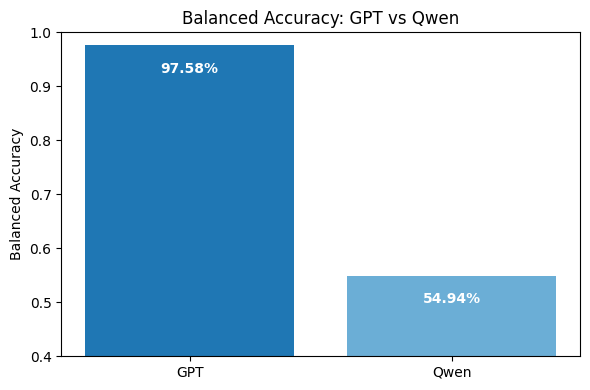

In [12]:
import matplotlib.pyplot as plt

models = ["GPT", "Qwen"]
balanced_acc = [0.9758, 0.5494]

plt.figure(figsize=(6, 4))

bars = plt.bar(
    models,
    balanced_acc,
    color=["#1f77b4", "#6baed6"]
)

plt.ylim(0.40, 1.00)
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy: GPT vs Qwen")

# Put text inside bars
for bar, v in zip(bars, balanced_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        v - 0.03,                 # push text inside the bar
        f"{v*100:.2f}%",
        ha="center",
        va="top",
        fontsize=10,
        color="white",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()
